In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns = None
import warnings

In [2]:
test = pd.read_csv('/kaggle/input/llm-prompt-recovery/test.csv')
test.head() 

,id,original_text,rewritten_text
0,-1,The competition dataset comprises text passage...,Here is your shanty: (Verse 1) The text is rew...


In [3]:
train = pd.read_csv('/kaggle/input/llm-prompt-recovery/train.csv')
train.head()

,id,original_text,rewrite_prompt,rewritten_text
0,-1,The competition dataset comprises text passage...,"Convert this into a sea shanty: """"""The competi...",Here is your shanty: (Verse 1) The text is rew...


In [5]:
combined = pd.concat([test,train])
combined.head()

,id,original_text,rewritten_text,rewrite_prompt
0,-1,The competition dataset comprises text passage...,Here is your shanty: (Verse 1) The text is rew...,NaN
0,-1,The competition dataset comprises text passage...,Here is your shanty: (Verse 1) The text is rew...,"Convert this into a sea shanty: """"""The competi..."


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 0
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              2 non-null      int64 
 1   original_text   2 non-null      object
 2   rewritten_text  2 non-null      object
 3   rewrite_prompt  1 non-null      object
dtypes: int64(1), object(3)
memory usage: 80.0+ bytes


In [6]:
combined.dtypes

id                 int64
original_text     object
rewritten_text    object
rewrite_prompt    object
dtype: object

In [7]:
combined.columns

Index(['id', 'original_text', 'rewritten_text', 'rewrite_prompt'], dtype='object')

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [9]:
combined.isnull().notnull()

,id,original_text,rewritten_text,rewrite_prompt
0,True,True,True,True
0,True,True,True,True


In [10]:
combined.shape

(2, 4)

In [6]:
cat_cols = combined.select_dtypes(include='object')

In [7]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print(''*50)

original_text

rewritten_text

rewrite_prompt



In [8]:
num_cols = combined.select_dtypes(include='number')

In [9]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print(''*50)

id



<Axes: >

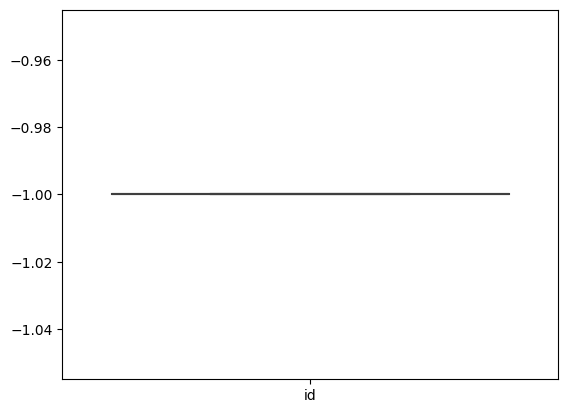

In [15]:
sns.boxplot(combined)

<Axes: >

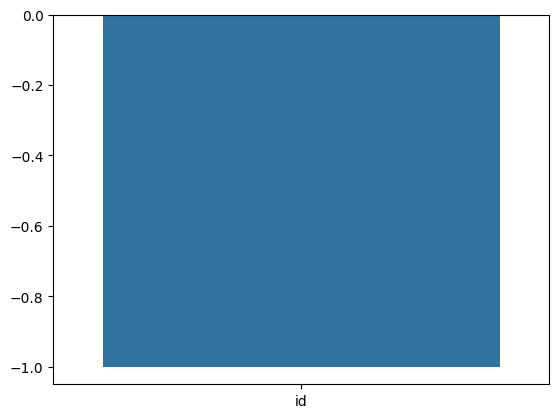

In [16]:
sns.barplot(combined)

<Axes: >

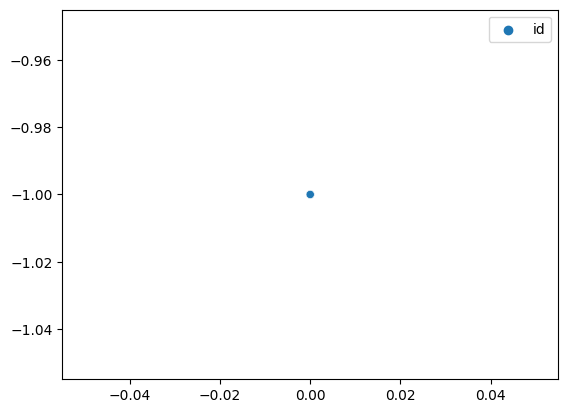

In [17]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

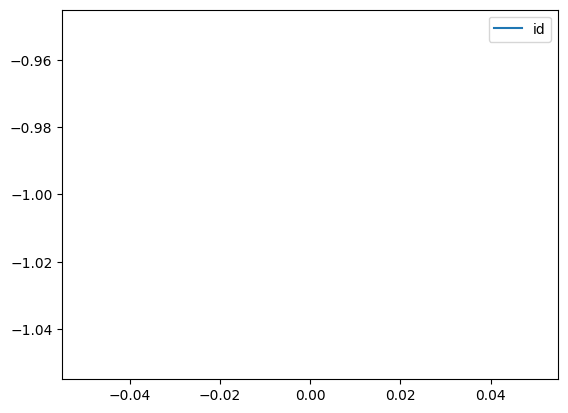

In [18]:
sns.lineplot(combined)

<Axes: >

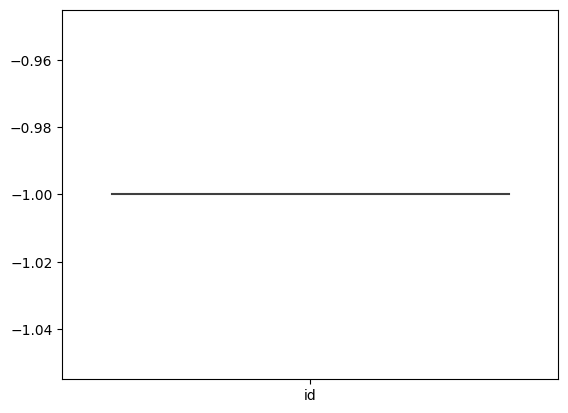

In [19]:
sns.violinplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_33/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(combined)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence thi

<Axes: ylabel='Density'>

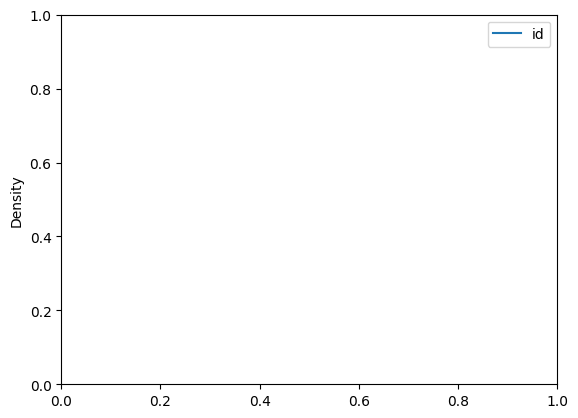

In [20]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

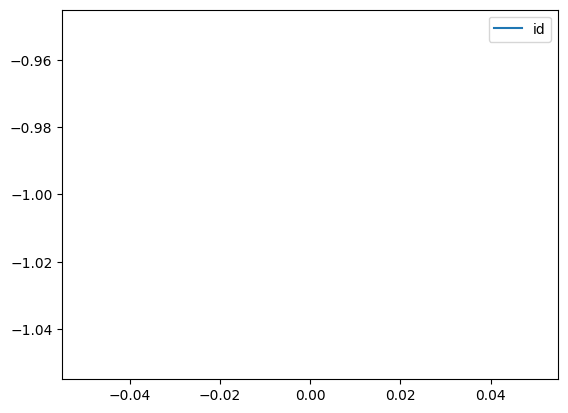

In [21]:
sns.lineplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


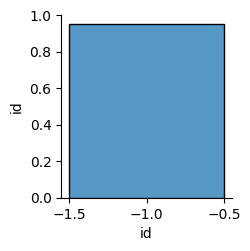

In [22]:
sns.pairplot(combined)

In [23]:
combined.skew

<bound method DataFrame.skew of    id                                      original_text  \
0  -1  The competition dataset comprises text passage...   
0  -1  The competition dataset comprises text passage...   

                                      rewritten_text  \
0  Here is your shanty: (Verse 1) The text is rew...   
0  Here is your shanty: (Verse 1) The text is rew...   

                                      rewrite_prompt  
0                                                NaN  
0  Convert this into a sea shanty: """The competi...  >

In [24]:
combined.kurt

<bound method DataFrame.kurt of    id                                      original_text  \
0  -1  The competition dataset comprises text passage...   
0  -1  The competition dataset comprises text passage...   

                                      rewritten_text  \
0  Here is your shanty: (Verse 1) The text is rew...   
0  Here is your shanty: (Verse 1) The text is rew...   

                                      rewrite_prompt  
0                                                NaN  
0  Convert this into a sea shanty: """The competi...  >

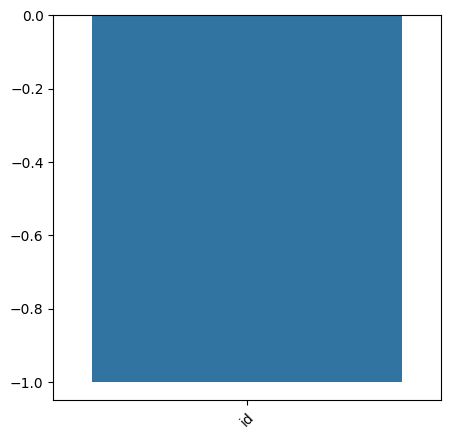

In [25]:
plt.figure(figsize=(5,5))
sns.barplot(data=combined);
plt.xticks(rotation=45);

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_33/2661856307.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=combined)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silenc

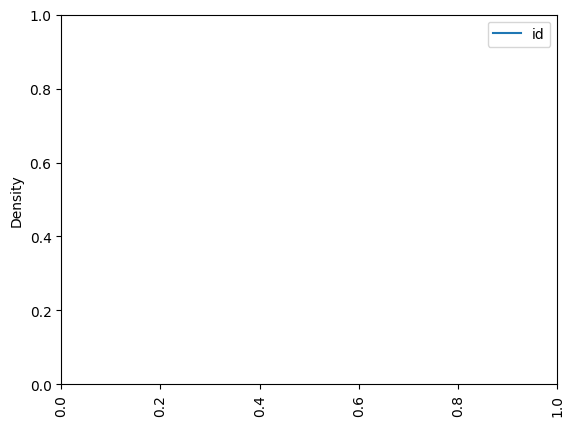

In [26]:

sns.kdeplot(data=combined)
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


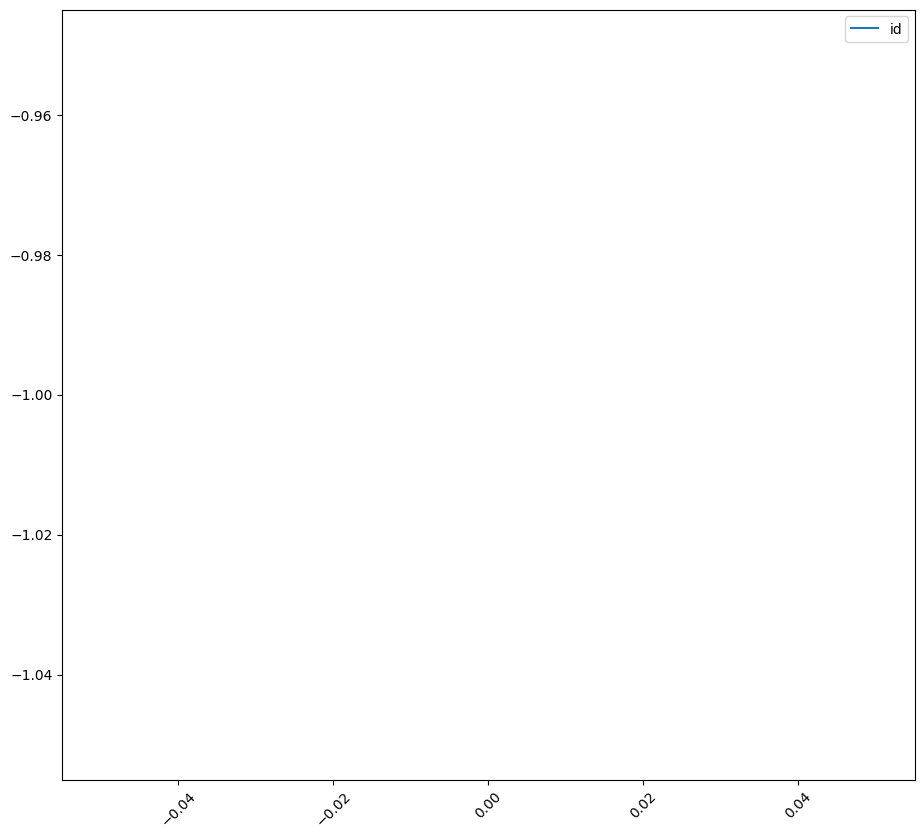

In [27]:
plt.figure(figsize=(11,10))
sns.lineplot(data=combined);
plt.xticks(rotation=45);

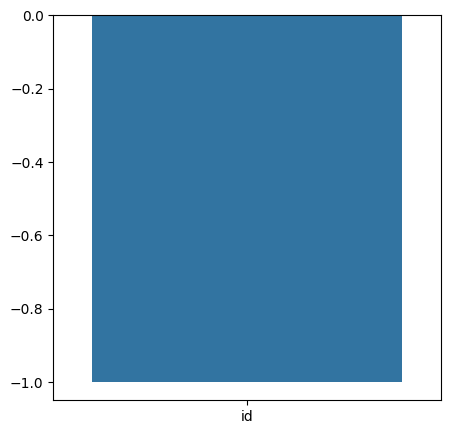

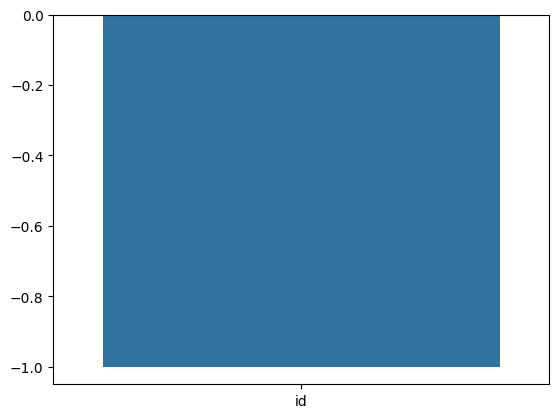

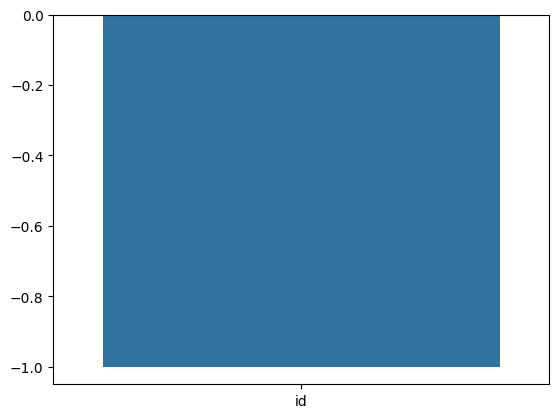

In [10]:

plt.figure(figsize=(5,5))
x = i
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.barplot(data=combined)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_33/2262024202.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=combined)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silenc

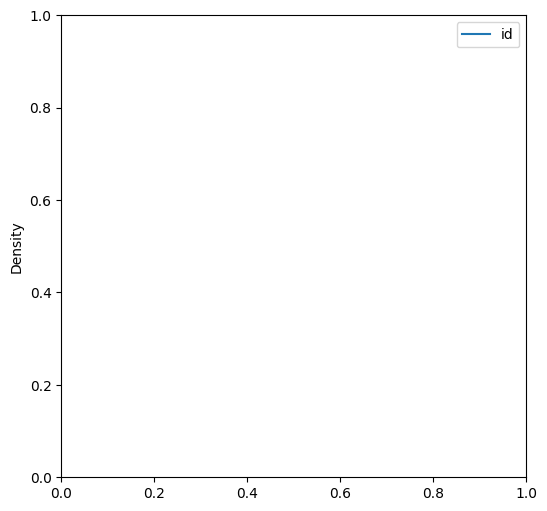

In [11]:
plt.figure(figsize=(6,6))
x = i
num_cols = combined.select_dtypes(include='number')
for i  in num_cols:
    sns.kdeplot(data=combined)
    print('\n')
    plt.show()

<Axes: ylabel='count'>

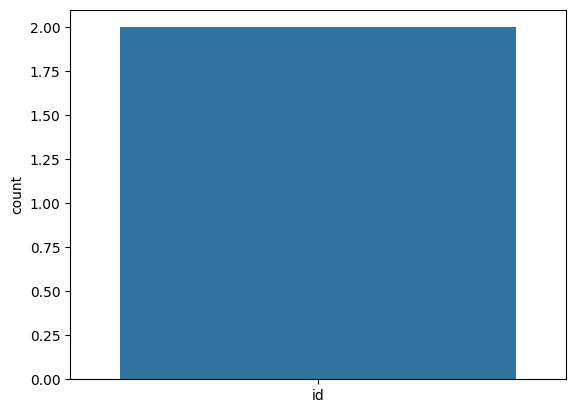

In [12]:
sns.countplot(combined)

In [13]:
combined.head()

,id,original_text,rewritten_text,rewrite_prompt
0,-1,The competition dataset comprises text passage...,Here is your shanty: (Verse 1) The text is rew...,NaN
0,-1,The competition dataset comprises text passage...,Here is your shanty: (Verse 1) The text is rew...,"Convert this into a sea shanty: """"""The competi..."


In [14]:
x = combined[['id']]

In [15]:
y = combined[['id']]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lr = LinearRegression()

In [20]:
lr.fit(x_train,y_train)

LinearRegression()

In [21]:
y_pred=lr.predict(x_test)


In [22]:
y_test.head(),y_pred[0:5]

(   id
 0  -1,
 array([[-1.]]))

In [23]:
from sklearn.metrics import mean_squared_error

In [24]:
mean_squared_error(y_test,y_pred)

0.0

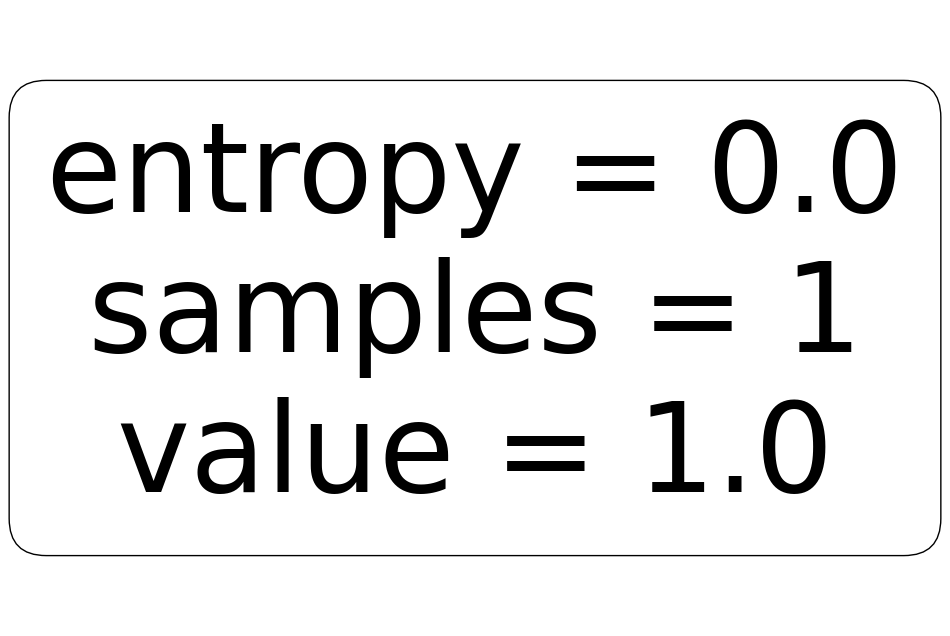

In [48]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Initialize and train the model
decision_tree_classification = DecisionTreeClassifier(criterion='entropy', random_state=10)
decision_tree = decision_tree_classification.fit(x_train, y_train)

# Plot the decision tree
plt.figure(figsize=(12,8))  # Set figure size for better visualization
plot_tree(decision_tree, max_depth=3, feature_names=x_train.columns, rounded=True)
plt.show()


In [95]:
y_pred_test = decision_tree.predict(x_test)  
y_pred_train = decision_tree.predict(x_train)  # Corrected variable name
print(decision_tree)


DecisionTreeClassifier(criterion='entropy', random_state=10)


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [62]:
print(len(y_train,),len(y_pred_train))

1 1


In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

/tmp/ipykernel_33/1408708486.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [68]:
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [80]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import cophenet

In [91]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load your dataset (ensure X exists)
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(x_test)  # Replace X with your dataset

# Now combined_scaled should exist
print(combined_scaled.shape)






(1, 1)
